# Experiment: BatchNorm 

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

torch.manual_seed(42)

In [2]:
train_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

print(f"Length of train data: {len(train_data)}")
print(f"Length of test data: {len(test_data)}")

Length of train data: 60000
Length of test data: 10000


In [3]:
class_names = train_data.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Length of train_dataloader: {len(train_dataloader)}, No. of images per batch: {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)}, No. of images per batch: {BATCH_SIZE}")

Length of train_dataloader: 1875, No. of images per batch: 32
Length of test_dataloader: 313, No. of images per batch: 32


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


In [6]:
from torchmetrics import Accuracy, Precision, Recall, F1Score

train_metrics = {
    "accuracy": Accuracy(task="multiclass", num_classes=10).to(device),
    "precision": Precision(task="multiclass", num_classes=10, average="weighted").to(device),
    "recall": Recall(task="multiclass", num_classes=10, average="weighted").to(device),
    "f1": F1Score(task="multiclass", num_classes=10, average="weighted").to(device)
}

test_metrics = {
    "accuracy": Accuracy(task="multiclass", num_classes=10).to(device),
    "precision": Precision(task="multiclass", num_classes=10, average="weighted").to(device),
    "recall": Recall(task="multiclass", num_classes=10, average="weighted").to(device),
    "f1": F1Score(task="multiclass", num_classes=10, average="weighted").to(device)
}

exp_results = []

In [7]:
from src.models import CNN
from src.train import train_step, test_step

epochs = 20
history = {
    "train": [],
    "test": []
}

exp0 = CNN().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp0.parameters(),
    lr=0.0005
)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-"*30)

    train_results = train_step(
        model=exp0,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        metrics=train_metrics,
        device=device
    )

    test_results = test_step(
        model=exp0,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=test_metrics,
        device=device
    )

    history["train"].append(train_results)
    history["test"].append(test_results)

    print(
        f"Train Loss: {train_results['loss']:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Train Precision: {train_results['precision']:.4f} | "
        f"Train Recall: {train_results['recall']:.4f} | "
        f"Train F1: {train_results['f1']:.4f}"
    )

    print(
        f"Test Loss: {test_results['loss']:.4f} | "
        f"Test Acc: {test_results['accuracy']:.4f} | "
        f"Test Precision: {test_results['precision']:.4f} | "
        f"Test Recall: {test_results['recall']:.4f} | "
        f"Test F1: {test_results['f1']:.4f}"
    )

exp_results.append({
    "dropout": 0.0,
    "batch_norm": False,
    "weight_decay": 0,
    "train_loss": history["train"][-1]["loss"],
    "test_loss": history["test"][-1]["loss"],
    "train_accuracy": history["train"][-1]["accuracy"],
    "test_accuracy": history["test"][-1]["accuracy"],
    "train_precision": history["train"][-1]["precision"],
    "test_precision": history["test"][-1]["precision"],
    "train_recall": history["train"][-1]["recall"],
    "test_recall": history["test"][-1]["recall"],
    "train_f1": history["train"][-1]["f1"],
    "test_f1": history["test"][-1]["f1"]
})


Epoch 1/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.4047 | Train Acc: 0.8547 | Train Precision: 0.8535 | Train Recall: 0.8547 | Train F1: 0.8538
Test Loss: 0.3323 | Test Acc: 0.8811 | Test Precision: 0.8850 | Test Recall: 0.8811 | Test F1: 0.8788

Epoch 2/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.2528 | Train Acc: 0.9086 | Train Precision: 0.9082 | Train Recall: 0.9086 | Train F1: 0.9083
Test Loss: 0.2666 | Test Acc: 0.9036 | Test Precision: 0.9040 | Test Recall: 0.9036 | Test F1: 0.9033

Epoch 3/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 /

In [8]:
from src.models import CNN
from src.train import train_step, test_step

epochs = 20
history = {
    "train": [],
    "test": []
}

exp1 = CNN(batch_norm=True, dropout=0.0).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp1.parameters(),
    lr=0.0005
)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-"*30)

    train_results = train_step(
        model=exp1,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        metrics=train_metrics,
        device=device
    )

    test_results = test_step(
        model=exp1,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=test_metrics,
        device=device
    )

    history["train"].append(train_results)
    history["test"].append(test_results)

    print(
        f"Train Loss: {train_results['loss']:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Train Precision: {train_results['precision']:.4f} | "
        f"Train Recall: {train_results['recall']:.4f} | "
        f"Train F1: {train_results['f1']:.4f}"
    )

    print(
        f"Test Loss: {test_results['loss']:.4f} | "
        f"Test Acc: {test_results['accuracy']:.4f} | "
        f"Test Precision: {test_results['precision']:.4f} | "
        f"Test Recall: {test_results['recall']:.4f} | "
        f"Test F1: {test_results['f1']:.4f}"
    )

exp_results.append({
    "dropout": 0.0,
    "batch_norm": True,
    "weight_decay": 0,
    "train_loss": history["train"][-1]["loss"],
    "test_loss": history["test"][-1]["loss"],
    "train_accuracy": history["train"][-1]["accuracy"],
    "test_accuracy": history["test"][-1]["accuracy"],
    "train_precision": history["train"][-1]["precision"],
    "test_precision": history["test"][-1]["precision"],
    "train_recall": history["train"][-1]["recall"],
    "test_recall": history["test"][-1]["recall"],
    "train_f1": history["train"][-1]["f1"],
    "test_f1": history["test"][-1]["f1"]
})


Epoch 1/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.3540 | Train Acc: 0.8732 | Train Precision: 0.8727 | Train Recall: 0.8732 | Train F1: 0.8729
Test Loss: 0.2766 | Test Acc: 0.8978 | Test Precision: 0.8983 | Test Recall: 0.8978 | Test F1: 0.8975

Epoch 2/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.2324 | Train Acc: 0.9147 | Train Precision: 0.9144 | Train Recall: 0.9147 | Train F1: 0.9145
Test Loss: 0.2419 | Test Acc: 0.9098 | Test Precision: 0.9120 | Test Recall: 0.9098 | Test F1: 0.9101

Epoch 3/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 /

In [9]:
from src.models import CNN
from src.train import train_step, test_step

epochs = 20
history = {
    "train": [],
    "test": []
}

exp2 = CNN(batch_norm=True, dropout=0.5).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp2.parameters(),
    lr=0.0005
)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-"*30)

    train_results = train_step(
        model=exp2,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        metrics=train_metrics,
        device=device
    )

    test_results = test_step(
        model=exp2,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=test_metrics,
        device=device
    )

    history["train"].append(train_results)
    history["test"].append(test_results)

    print(
        f"Train Loss: {train_results['loss']:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Train Precision: {train_results['precision']:.4f} | "
        f"Train Recall: {train_results['recall']:.4f} | "
        f"Train F1: {train_results['f1']:.4f}"
    )

    print(
        f"Test Loss: {test_results['loss']:.4f} | "
        f"Test Acc: {test_results['accuracy']:.4f} | "
        f"Test Precision: {test_results['precision']:.4f} | "
        f"Test Recall: {test_results['recall']:.4f} | "
        f"Test F1: {test_results['f1']:.4f}"
    )

exp_results.append({
    "dropout": 0.5,
    "batch_norm": True,
    "weight_decay": 0,
    "train_loss": history["train"][-1]["loss"],
    "test_loss": history["test"][-1]["loss"],
    "train_accuracy": history["train"][-1]["accuracy"],
    "test_accuracy": history["test"][-1]["accuracy"],
    "train_precision": history["train"][-1]["precision"],
    "test_precision": history["test"][-1]["precision"],
    "train_recall": history["train"][-1]["recall"],
    "test_recall": history["test"][-1]["recall"],
    "train_f1": history["train"][-1]["f1"],
    "test_f1": history["test"][-1]["f1"]
})


Epoch 1/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.5134 | Train Acc: 0.8158 | Train Precision: 0.8137 | Train Recall: 0.8158 | Train F1: 0.8144
Test Loss: 0.3135 | Test Acc: 0.8870 | Test Precision: 0.8894 | Test Recall: 0.8870 | Test F1: 0.8874

Epoch 2/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.3541 | Train Acc: 0.8726 | Train Precision: 0.8719 | Train Recall: 0.8726 | Train F1: 0.8721
Test Loss: 0.2739 | Test Acc: 0.8984 | Test Precision: 0.8999 | Test Recall: 0.8984 | Test F1: 0.8981

Epoch 3/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 /

In [10]:
from src.models import CNN
from src.train import train_step, test_step

epochs = 20
history = {
    "train": [],
    "test": []
}

exp3 = CNN(batch_norm=True, dropout=0.5).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp3.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-"*30)

    train_results = train_step(
        model=exp3,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        metrics=train_metrics,
        device=device
    )

    test_results = test_step(
        model=exp3,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=test_metrics,
        device=device
    )

    history["train"].append(train_results)
    history["test"].append(test_results)

    print(
        f"Train Loss: {train_results['loss']:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Train Precision: {train_results['precision']:.4f} | "
        f"Train Recall: {train_results['recall']:.4f} | "
        f"Train F1: {train_results['f1']:.4f}"
    )

    print(
        f"Test Loss: {test_results['loss']:.4f} | "
        f"Test Acc: {test_results['accuracy']:.4f} | "
        f"Test Precision: {test_results['precision']:.4f} | "
        f"Test Recall: {test_results['recall']:.4f} | "
        f"Test F1: {test_results['f1']:.4f}"
    )

exp_results.append({
    "dropout": 0.5,
    "batch_norm": True,
    "weight_decay": 1e-4,
    "train_loss": history["train"][-1]["loss"],
    "test_loss": history["test"][-1]["loss"],
    "train_accuracy": history["train"][-1]["accuracy"],
    "test_accuracy": history["test"][-1]["accuracy"],
    "train_precision": history["train"][-1]["precision"],
    "test_precision": history["test"][-1]["precision"],
    "train_recall": history["train"][-1]["recall"],
    "test_recall": history["test"][-1]["recall"],
    "train_f1": history["train"][-1]["f1"],
    "test_f1": history["test"][-1]["f1"]
})


Epoch 1/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.5176 | Train Acc: 0.8131 | Train Precision: 0.8111 | Train Recall: 0.8131 | Train F1: 0.8118
Test Loss: 0.3440 | Test Acc: 0.8691 | Test Precision: 0.8781 | Test Recall: 0.8691 | Test F1: 0.8704

Epoch 2/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.3637 | Train Acc: 0.8691 | Train Precision: 0.8683 | Train Recall: 0.8691 | Train F1: 0.8686
Test Loss: 0.2869 | Test Acc: 0.8937 | Test Precision: 0.8949 | Test Recall: 0.8937 | Test F1: 0.8918

Epoch 3/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 /

In [11]:
df = pd.DataFrame(exp_results)
df

,dropout,batch_norm,weight_decay,train_loss,test_loss,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
0,0.0,False,0.0000,0.009571,0.582202,0.996800,0.9181,0.996800,0.922133,0.996800,0.9181,0.996800,0.918840
1,0.0,True,0.0000,0.011302,0.494556,0.996283,0.9188,0.996283,0.918690,0.996283,0.9188,0.996283,0.918308
2,0.5,True,0.0000,0.071266,0.293159,0.972033,0.9313,0.972032,0.931360,0.972033,0.9313,0.972027,0.931173
3,0.5,True,0.0001,0.095381,0.230455,0.963767,0.9309,0.963740,0.931126,0.963767,0.9309,0.963747,0.930891


In [12]:
new_df = df[['dropout', 'batch_norm', 'weight_decay', 'train_loss', 'test_loss', 'train_accuracy', 'test_accuracy']]

new_df

,dropout,batch_norm,weight_decay,train_loss,test_loss,train_accuracy,test_accuracy
0,0.0,False,0.0000,0.009571,0.582202,0.996800,0.9181
1,0.0,True,0.0000,0.011302,0.494556,0.996283,0.9188
2,0.5,True,0.0000,0.071266,0.293159,0.972033,0.9313
3,0.5,True,0.0001,0.095381,0.230455,0.963767,0.9309


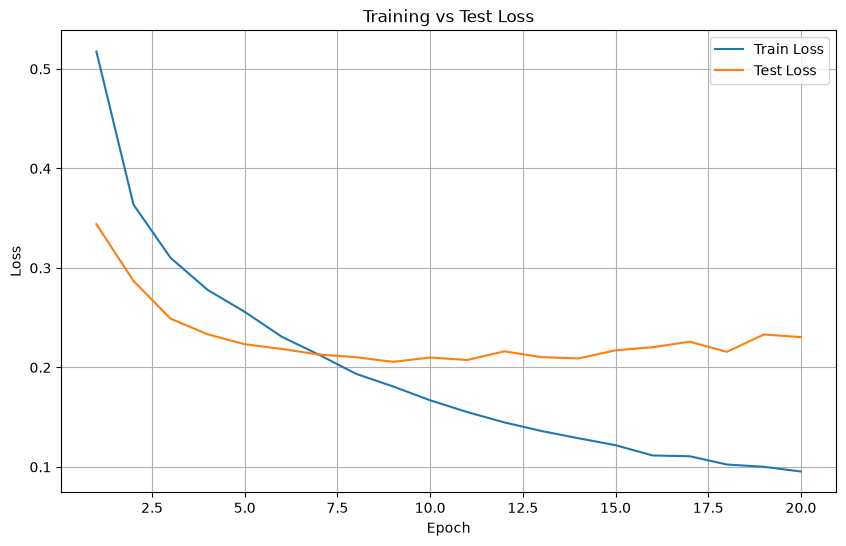

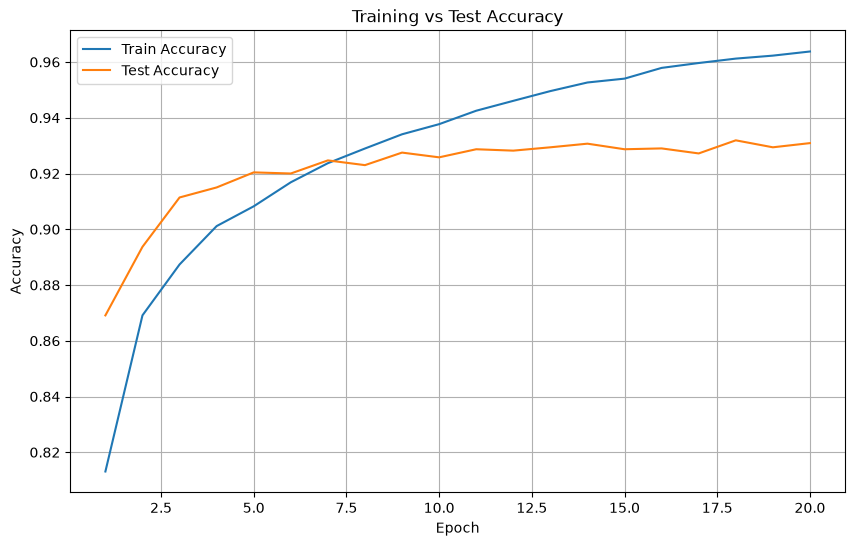

In [15]:
from src.plots import plot_metric

plot_metric(history, "loss")
plot_metric(history, "accuracy")